# Event–Market Gold EDA
EDA riêng cho point-in-time join, event-window coverage và abnormal return.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
gold = pd.read_parquet(ROOT / 'data_lake/gold/news_market_impact')
for c in ['event_date_vn','t0_date','anchor_date_t_minus_1','session_date']:
    gold[c] = pd.to_datetime(gold[c], errors='coerce')
print(f'Gold rows: {len(gold):,}')

Gold rows: 44,199


In [2]:
pairs = gold.drop_duplicates(['event_id','ticker']).copy()
bad_t0 = np.where(pairs.published_after_close, pairs.t0_date <= pairs.event_date_vn, pairs.t0_date < pairs.event_date_vn)
quality = pd.Series({
    'rows': len(gold),
    'event_ticker_pairs': len(pairs),
    'events': gold.event_id.nunique(),
    'tickers': gold.ticker.nunique(),
    'duplicate_window_keys': gold.duplicated(['event_id','ticker','relative_session']).sum(),
    'published_after_close': pairs.published_after_close.sum(),
    'bad_t0': bad_t0.sum(),
    'bad_anchor': (pairs.anchor_date_t_minus_1 >= pairs.t0_date).sum(),
}, name='value').to_frame()
display(quality)

,value
rows,44199
event_ticker_pairs,4911
events,2879
tickers,30
duplicate_window_keys,0
published_after_close,1728
bad_t0,0
bad_anchor,0


,requested,available,availability_pct
relative_session,,,
-5,4911,4886,99.49
-3,4911,4887,99.51
-2,4911,4887,99.51
-1,4911,4887,99.51
0,4911,4911,100.00
1,4911,4887,99.51
2,4911,4860,98.96
3,4911,4832,98.39
5,4911,4830,98.35


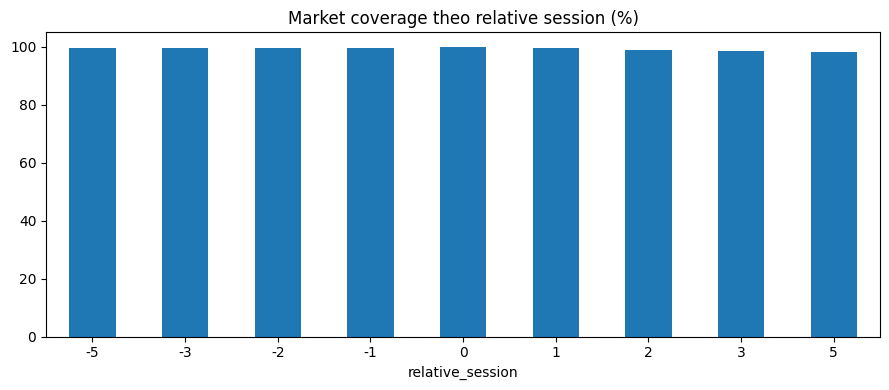

In [3]:
coverage = gold.groupby('relative_session').agg(
    requested=('event_id','size'),
    available=('has_market_data','sum'),
)
coverage['availability_pct'] = (100*coverage.available/coverage.requested).round(2)
display(coverage)
coverage.availability_pct.plot.bar(figsize=(9,4), ylim=(0,105), title='Market coverage theo relative session (%)', rot=0)
plt.tight_layout(); plt.show()

,count,mean,median,std,se,ci95_low,ci95_high
relative_session,,,,,,,
-5,4886,-0.081,0.173,2.845,0.041,-0.161,-0.001
-3,4887,-0.094,0.063,2.076,0.030,-0.152,-0.036
-2,4887,-0.078,0.043,1.515,0.022,-0.120,-0.035
-1,4887,0.000,0.000,0.000,0.000,0.000,0.000
0,4887,0.020,-0.064,1.640,0.023,-0.026,0.066
1,4863,0.069,-0.104,2.355,0.034,0.003,0.135
2,4836,0.080,-0.180,2.710,0.039,0.004,0.156
3,4808,0.063,-0.146,2.990,0.043,-0.021,0.148
5,4806,0.079,-0.287,3.554,0.051,-0.021,0.180


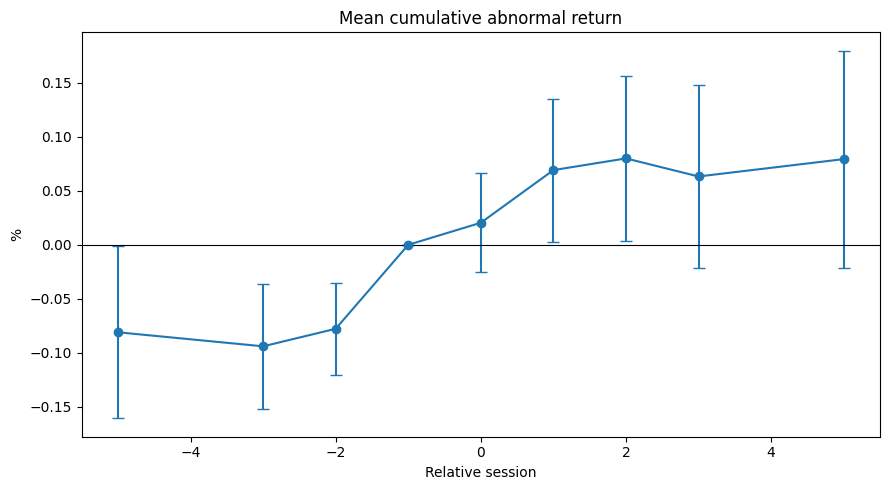

In [4]:
available = gold[gold.has_market_data & gold.abnormal_return.notna()].copy()
stats = available.groupby('relative_session').abnormal_return.agg(['count','mean','median','std'])
stats['se'] = stats['std']/np.sqrt(stats['count'])
stats['ci95_low'] = stats['mean'] - 1.96*stats['se']
stats['ci95_high'] = stats['mean'] + 1.96*stats['se']
display((100*stats).assign(count=stats['count']).round(3))
fig, ax = plt.subplots(figsize=(9,5))
x = stats.index.to_numpy()
mean = (100*stats['mean']).to_numpy()
error = (100*1.96*stats['se']).to_numpy()
ax.errorbar(x, mean, yerr=error, marker='o', capsize=4)
ax.axhline(0,color='black',linewidth=.8)
ax.set(title='Mean cumulative abnormal return', xlabel='Relative session', ylabel='%')
plt.tight_layout(); plt.show()

In [5]:
focus = available[available.relative_session.isin([0,1,3,5])]
timing = focus.groupby(['published_after_close','relative_session']).agg(
    events=('event_id','size'), mean_abnormal=('abnormal_return','mean'),
).reset_index()
timing['mean_abnormal_pct'] = (100*timing.mean_abnormal).round(3)
display(timing)

,published_after_close,relative_session,events,mean_abnormal,mean_abnormal_pct
0,False,0,3168,0.000086,0.009
1,False,1,3168,0.000860,0.086
2,False,3,3148,0.000464,0.046
3,False,5,3146,0.000790,0.079
4,True,0,1719,0.000423,0.042
5,True,1,1695,0.000379,0.038
6,True,3,1660,0.000956,0.096
7,True,5,1660,0.000801,0.080


In [6]:
ticker_t5 = available[available.relative_session.eq(5)].groupby('ticker').agg(
    events=('event_id','size'), mean_abnormal=('abnormal_return','mean'),
).query('events >= 20').sort_values('mean_abnormal')
ticker_t5['mean_abnormal_pct'] = (100*ticker_t5.mean_abnormal).round(3)
display(ticker_t5[['events','mean_abnormal_pct']])
print('Cảnh báo: các thống kê này mô tả tương quan, không chứng minh tác động nhân quả.')

,events,mean_abnormal_pct
ticker,,
SSB,41,-3.010
MWG,68,-1.128
SHB,87,-0.557
VJC,20,-0.553
VCB,293,-0.431
VNM,39,-0.418
VHM,41,-0.354
HPG,31,-0.299
BID,174,-0.181


Cảnh báo: các thống kê này mô tả tương quan, không chứng minh tác động nhân quả.
